In [7]:
# Confirm dashboard files

powerbi_files = [
    "powerbi_dashboard_transactions.csv",
    "powerbi_dashboard_kpis.csv",
    "eda_top_areas_transactions.csv",
    "eda_top_areas_sales.csv",
    "eda_area_price_summary.csv",
    "eda_monthly_trend.csv",
    "eda_property_type_summary.csv",
    "ml_final_model_summary.csv",
    "forecast_next_12_months_average_price.csv"
]

for file in powerbi_files:
    file_path = PROCESSED_DATA_DIR / file
    print(file, "✅ exists" if file_path.exists() else "❌ missing")

powerbi_dashboard_transactions.csv ✅ exists
powerbi_dashboard_kpis.csv ✅ exists
eda_top_areas_transactions.csv ✅ exists
eda_top_areas_sales.csv ✅ exists
eda_area_price_summary.csv ✅ exists
eda_monthly_trend.csv ✅ exists
eda_property_type_summary.csv ✅ exists
ml_final_model_summary.csv ✅ exists
forecast_next_12_months_average_price.csv ✅ exists


In [6]:
# Save Power BI ready files

dashboard_data_path = PROCESSED_DATA_DIR / "powerbi_dashboard_transactions.csv"
dashboard_kpis_path = PROCESSED_DATA_DIR / "powerbi_dashboard_kpis.csv"

dashboard_df.to_csv(dashboard_data_path, index=False)
dashboard_kpis.to_csv(dashboard_kpis_path, index=False)

print("Power BI dashboard dataset saved to:", dashboard_data_path)
print("Power BI KPI table saved to:", dashboard_kpis_path)

Power BI dashboard dataset saved to: c:\Projects\dubai-real-estate-price-intelligence-dashboard\data\processed\powerbi_dashboard_transactions.csv
Power BI KPI table saved to: c:\Projects\dubai-real-estate-price-intelligence-dashboard\data\processed\powerbi_dashboard_kpis.csv


In [5]:
# Create dashboard KPI summary table

dashboard_kpis = pd.DataFrame({
    "metric": [
        "Total Transactions",
        "Total Sales Value AED",
        "Average Transaction Price AED",
        "Median Transaction Price AED",
        "Average Price per Sqm AED",
        "Total Areas",
        "Total Property Types",
        "Start Date",
        "End Date"
    ],
    "value": [
        dashboard_df["transaction_id"].nunique(),
        dashboard_df["actual_worth"].sum(),
        dashboard_df["actual_worth"].mean(),
        dashboard_df["actual_worth"].median(),
        dashboard_df["price_per_sqm"].mean(),
        dashboard_df["area_name_en"].nunique(),
        dashboard_df["property_type_en"].nunique(),
        dashboard_df["transaction_date"].min(),
        dashboard_df["transaction_date"].max()
    ]
})

dashboard_kpis

,metric,value
0,Total Transactions,1044151
1,Total Sales Value AED,2670352977548.0
2,Average Transaction Price AED,2557439.467613
3,Median Transaction Price AED,1245500.0
4,Average Price per Sqm AED,12858.063068
5,Total Areas,247
6,Total Property Types,4
7,Start Date,1995-03-07 00:00:00
8,End Date,2023-03-17 00:00:00


In [4]:
# Add business-friendly columns

dashboard_df["transaction_date"] = pd.to_datetime(dashboard_df["instance_date"], errors="coerce")

dashboard_df["sales_value_million"] = dashboard_df["actual_worth"] / 1_000_000
dashboard_df["sales_value_billion"] = dashboard_df["actual_worth"] / 1_000_000_000

dashboard_df["area_size_sqm"] = dashboard_df["procedure_area"]
dashboard_df["price_per_sqm"] = dashboard_df["meter_sale_price"]

dashboard_df["month_name"] = dashboard_df["transaction_date"].dt.month_name()
dashboard_df["year_month_sort"] = dashboard_df["transaction_date"].dt.strftime("%Y-%m")

dashboard_df.head()

,transaction_id,instance_date,transaction_year,transaction_month,transaction_quarter,transaction_year_month,area_name_en,property_type_en,property_sub_type_en,property_usage_en,...,nearest_metro_en,nearest_mall_en,nearest_landmark_en,transaction_date,sales_value_million,sales_value_billion,area_size_sqm,price_per_sqm,month_name,year_month_sort
0,1-11-2001-165,2001-02-24,2001.0,2.0,1.0,2001-02,Al Wasl,Land,Unknown,Commercial,...,Unknown,Unknown,Unknown,2001-02-24,1.35,0.00135,1393.55,968.75,February,2001-02
1,3-9-2004-223,2004-12-13,2004.0,12.0,4.0,2004-12,Al Hudaiba,Villa,Unknown,Commercial,...,Al Jafiliya Metro Station,Dubai Mall,Burj Khalifa,2004-12-13,2.79,0.00279,1728.00,1614.58,December,2004-12
2,2-13-1996-119,2001-03-12,2001.0,3.0,1.0,2001-03,Burj Khalifa,Land,Unknown,Commercial,...,Unknown,Unknown,Unknown,2001-03-12,20.00,0.02000,929.03,21527.83,March,2001-03
3,2-14-2005-222,2005-09-20,2005.0,9.0,3.0,2005-09,Oud Metha,Building,Unknown,Residential / Commercial,...,Oud Metha Metro Station,Dubai Mall,Dubai International Airport,2005-09-20,25.00,0.02500,2673.28,9351.81,September,2005-09
4,3-9-2012-874,2012-10-11,2012.0,10.0,4.0,2012-10,Al Bada,Villa,Unknown,Residential,...,Trade Centre Metro Station,Dubai Mall,Burj Khalifa,2012-10-11,9.00,0.00900,1541.17,5839.72,October,2012-10


In [3]:
# Create dashboard-ready dataset for Power BI

dashboard_columns = [
    "transaction_id",
    "instance_date",
    "transaction_year",
    "transaction_month",
    "transaction_quarter",
    "transaction_year_month",
    "area_name_en",
    "property_type_en",
    "property_sub_type_en",
    "property_usage_en",
    "reg_type_en",
    "rooms_en",
    "has_parking",
    "procedure_area",
    "actual_worth",
    "meter_sale_price",
    "nearest_metro_en",
    "nearest_mall_en",
    "nearest_landmark_en"
]

dashboard_columns = [col for col in dashboard_columns if col in df.columns]

dashboard_df = df[dashboard_columns].copy()

print("Dashboard dataset shape:", dashboard_df.shape)

dashboard_df.head()

Dashboard dataset shape: (1044151, 19)


,transaction_id,instance_date,transaction_year,transaction_month,transaction_quarter,transaction_year_month,area_name_en,property_type_en,property_sub_type_en,property_usage_en,reg_type_en,rooms_en,has_parking,procedure_area,actual_worth,meter_sale_price,nearest_metro_en,nearest_mall_en,nearest_landmark_en
0,1-11-2001-165,2001-02-24,2001.0,2.0,1.0,2001-02,Al Wasl,Land,Unknown,Commercial,Existing Properties,Unknown,0,1393.55,1350000.0,968.75,Unknown,Unknown,Unknown
1,3-9-2004-223,2004-12-13,2004.0,12.0,4.0,2004-12,Al Hudaiba,Villa,Unknown,Commercial,Existing Properties,Unknown,0,1728.00,2790000.0,1614.58,Al Jafiliya Metro Station,Dubai Mall,Burj Khalifa
2,2-13-1996-119,2001-03-12,2001.0,3.0,1.0,2001-03,Burj Khalifa,Land,Unknown,Commercial,Existing Properties,Unknown,0,929.03,20000000.0,21527.83,Unknown,Unknown,Unknown
3,2-14-2005-222,2005-09-20,2005.0,9.0,3.0,2005-09,Oud Metha,Building,Unknown,Residential / Commercial,Existing Properties,Unknown,0,2673.28,25000000.0,9351.81,Oud Metha Metro Station,Dubai Mall,Dubai International Airport
4,3-9-2012-874,2012-10-11,2012.0,10.0,4.0,2012-10,Al Bada,Villa,Unknown,Residential,Existing Properties,Unknown,0,1541.17,9000000.0,5839.72,Trade Centre Metro Station,Dubai Mall,Burj Khalifa


In [2]:
# Reload cleaned dataset for dashboard preparation

import pandas as pd
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"

file_path = PROCESSED_DATA_DIR / "dubai_real_estate_transactions_cleaned.csv"

df = pd.read_csv(file_path, low_memory=False)

df["instance_date"] = pd.to_datetime(df["instance_date"], errors="coerce")

print("Dataset loaded successfully for dashboard prep.")
print("Shape:", df.shape)

Dataset loaded successfully for dashboard prep.
Shape: (1044151, 27)


In [25]:
# Final EDA insights for report

print("EDA Completed Successfully")
print("=" * 50)

print("Total transactions analyzed:", df["transaction_id"].nunique())
print("Date range:", df["instance_date"].min(), "to", df["instance_date"].max())
print("Total sales value AED:", round(df["actual_worth"].sum(), 2))
print("Average transaction value AED:", round(df["actual_worth"].mean(), 2))
print("Median transaction value AED:", round(df["actual_worth"].median(), 2))
print("Average price per sqm AED:", round(df["meter_sale_price"].mean(), 2))

print("\nTop area by transaction count:")
print(top_areas_transactions.iloc[0]["area_name_en"], "-", top_areas_transactions.iloc[0]["total_transactions"])

print("\nTop area by total sales value:")
print(top_areas_sales.iloc[0]["area_name_en"], "-", round(top_areas_sales.iloc[0]["total_sales_value"], 2))

print("\nMost active property type:")
print(property_type_summary.iloc[0]["property_type_en"], "-", property_type_summary.iloc[0]["total_transactions"])

EDA Completed Successfully
Total transactions analyzed: 1044151
Date range: 1995-03-07 00:00:00 to 2023-03-17 00:00:00
Total sales value AED: 2670352977548.0
Average transaction value AED: 2557439.47
Median transaction value AED: 1245500.0
Average price per sqm AED: 12858.06

Top area by transaction count:
Marsa Dubai - 105035

Top area by total sales value:
Marsa Dubai - 215443844615.0

Most active property type:
Unit - 720974


In [24]:
# Save EDA summary tables

top_areas_transactions.to_csv(PROCESSED_DATA_DIR / "eda_top_areas_transactions.csv", index=False)
top_areas_sales.to_csv(PROCESSED_DATA_DIR / "eda_top_areas_sales.csv", index=False)
property_type_summary.to_csv(PROCESSED_DATA_DIR / "eda_property_type_summary.csv", index=False)
monthly_trend.to_csv(PROCESSED_DATA_DIR / "eda_monthly_trend.csv", index=False)
yearly_summary.to_csv(PROCESSED_DATA_DIR / "eda_yearly_summary.csv", index=False)
area_price_summary.to_csv(PROCESSED_DATA_DIR / "eda_area_price_summary.csv", index=False)
area_property_summary.to_csv(PROCESSED_DATA_DIR / "eda_area_property_summary.csv", index=False)
property_subtype_summary.to_csv(PROCESSED_DATA_DIR / "eda_property_subtype_summary.csv", index=False)
reg_type_summary.to_csv(PROCESSED_DATA_DIR / "eda_reg_type_summary.csv", index=False)
parking_summary.to_csv(PROCESSED_DATA_DIR / "eda_parking_summary.csv", index=False)

print("EDA summary tables saved successfully.")

EDA summary tables saved successfully.


In [23]:
# Parking availability analysis

parking_summary = (
    df.groupby("has_parking")
    .agg(
        total_transactions=("transaction_id", "count"),
        average_price=("actual_worth", "mean"),
        median_price=("actual_worth", "median"),
        average_price_per_sqm=("meter_sale_price", "mean")
    )
    .sort_values("total_transactions", ascending=False)
    .reset_index()
)

parking_summary

,has_parking,total_transactions,average_price,median_price,average_price_per_sqm
0,1,627007,"1,511,646.38","1,030,904.00","15,879.83"
1,0,417144,"4,129,365.67","1,769,000.00","8,316.05"


In [22]:
# Registration type analysis

reg_type_summary = (
    df.groupby("reg_type_en")
    .agg(
        total_transactions=("transaction_id", "count"),
        total_sales_value=("actual_worth", "sum"),
        average_price=("actual_worth", "mean"),
        average_price_per_sqm=("meter_sale_price", "mean")
    )
    .sort_values("total_transactions", ascending=False)
    .reset_index()
)

reg_type_summary

,reg_type_en,total_transactions,total_sales_value,average_price,average_price_per_sqm
0,Existing Properties,735500,"2,159,901,687,481.00","2,936,644.03","9,734.77"
1,Off-Plan Properties,308651,"510,451,290,067.00","1,653,813.82","20,300.72"


In [21]:
# Top property sub-types by transaction count

property_subtype_summary = (
    df.groupby("property_sub_type_en")
    .agg(
        total_transactions=("transaction_id", "count"),
        total_sales_value=("actual_worth", "sum"),
        average_price=("actual_worth", "mean"),
        average_price_per_sqm=("meter_sale_price", "mean")
    )
    .sort_values("total_transactions", ascending=False)
    .reset_index()
)

property_subtype_summary.head(15)

,property_sub_type_en,total_transactions,total_sales_value,average_price,average_price_per_sqm
0,Flat,614190,"842,117,146,024.00","1,371,102.01","15,007.85"
1,Unknown,236496,"1,464,882,631,269.00","6,194,111.66","7,395.19"
2,Villa,86520,"172,407,251,259.00","1,992,686.68","7,989.89"
3,Office,60392,"100,881,784,848.00","1,670,449.48","11,554.05"
4,Hotel Apartment,22228,"50,726,358,394.00","2,282,092.78","23,000.04"
5,Shop,12269,"20,793,531,609.00","1,694,802.48","14,564.87"
6,Hotel Rooms,10458,"13,164,036,747.00","1,258,752.80","35,477.49"
7,Workshop,517,"216,568,096.00","418,893.80","5,407.82"
8,Stacked Townhouses,364,"383,668,214.00","1,054,033.55","5,046.57"
9,Store,321,"24,337,759.00","75,818.56","7,742.93"


In [20]:
# Area and property type combined analysis

area_property_summary = (
    df.groupby(["area_name_en", "property_type_en"])
    .agg(
        total_transactions=("transaction_id", "count"),
        total_sales_value=("actual_worth", "sum"),
        average_price=("actual_worth", "mean"),
        median_price=("actual_worth", "median"),
        average_price_per_sqm=("meter_sale_price", "mean")
    )
    .reset_index()
    .sort_values("total_transactions", ascending=False)
)

area_property_summary.head(20)

,area_name_en,property_type_en,total_transactions,total_sales_value,average_price,median_price,average_price_per_sqm
421,Marsa Dubai,Unit,104492,"201,627,336,036.00","1,929,595.91","1,446,650.00","15,707.42"
328,Business Bay,Unit,73905,"115,354,070,952.00","1,560,842.58","1,236,000.00","15,842.55"
237,Al Thanyah Fifth,Unit,62908,"67,164,068,831.00","1,067,655.45","861,000.00","9,822.38"
324,Burj Khalifa,Unit,53998,"152,689,512,022.00","2,827,688.29","2,054,944.00","21,900.67"
273,Al Warsan First,Unit,47159,"18,120,478,666.00","384,242.22","345,000.00","6,404.30"
32,Al Barsha South Fourth,Unit,46818,"34,463,653,285.00","736,119.72","640,920.00","9,688.34"
499,Palm Jumeirah,Unit,28562,"92,525,689,212.00","3,239,468.15","2,250,000.00","17,654.65"
91,Al Hebiah Fourth,Unit,26643,"19,036,675,124.00","714,509.44","630,000.00","9,962.83"
234,Al Thanayah Fourth,Villa,26243,"69,183,849,152.00","2,636,278.21","1,825,000.00","5,842.22"
371,Jabal Ali First,Unit,26048,"16,510,754,792.00","633,858.83","534,536.50","8,806.87"


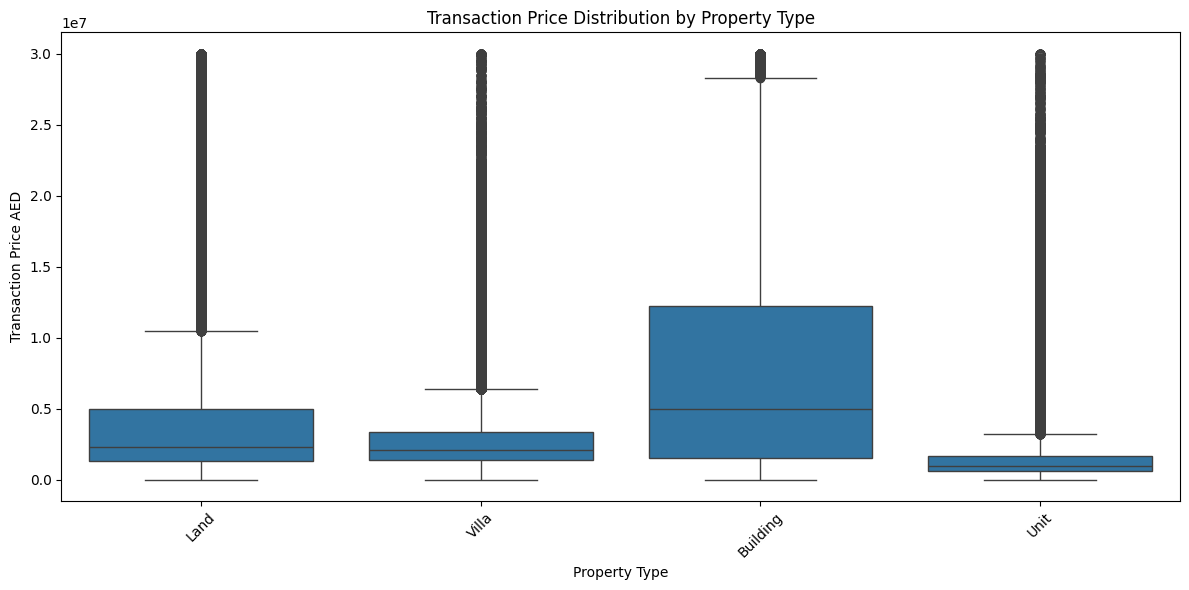

In [19]:
# Boxplot: Transaction price by property type
# Using 99th percentile limit to make chart readable

plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df[df["actual_worth"] <= price_99],
    x="property_type_en",
    y="actual_worth"
)

plt.title("Transaction Price Distribution by Property Type")
plt.xlabel("Property Type")
plt.ylabel("Transaction Price AED")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(FIGURES_DIR / "price_distribution_by_property_type.png", dpi=300, bbox_inches="tight")
plt.show()

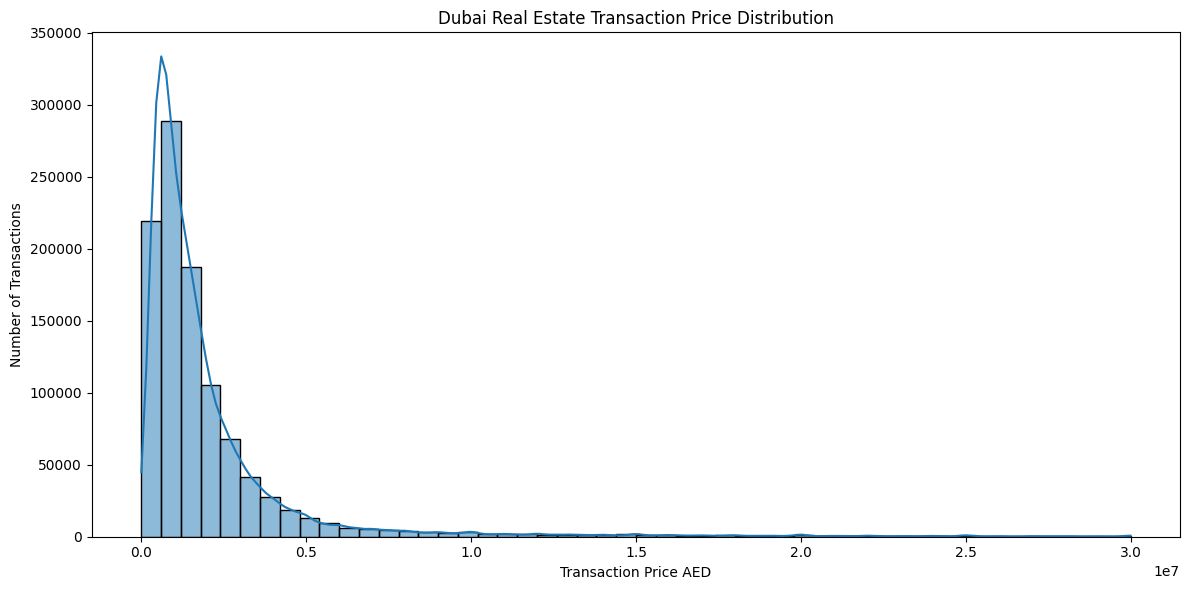

In [18]:
# Histogram: Transaction price distribution
# Using 99th percentile limit to reduce extreme outlier effect

price_99 = df["actual_worth"].quantile(0.99)

plt.figure(figsize=(12, 6))
sns.histplot(
    data=df[df["actual_worth"] <= price_99],
    x="actual_worth",
    bins=50,
    kde=True
)

plt.title("Dubai Real Estate Transaction Price Distribution")
plt.xlabel("Transaction Price AED")
plt.ylabel("Number of Transactions")
plt.tight_layout()

plt.savefig(FIGURES_DIR / "transaction_price_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

In [17]:
# Price distribution summary

price_summary = df["actual_worth"].describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99])

price_summary

count    1,044,151.00
mean     2,557,439.47
std      5,968,263.75
min              1.00
1%         198,750.00
5%         320,000.00
25%        680,400.00
50%      1,245,500.00
75%      2,285,490.50
95%      7,409,880.50
99%     30,000,000.00
max     99,971,250.00
Name: actual_worth, dtype: float64

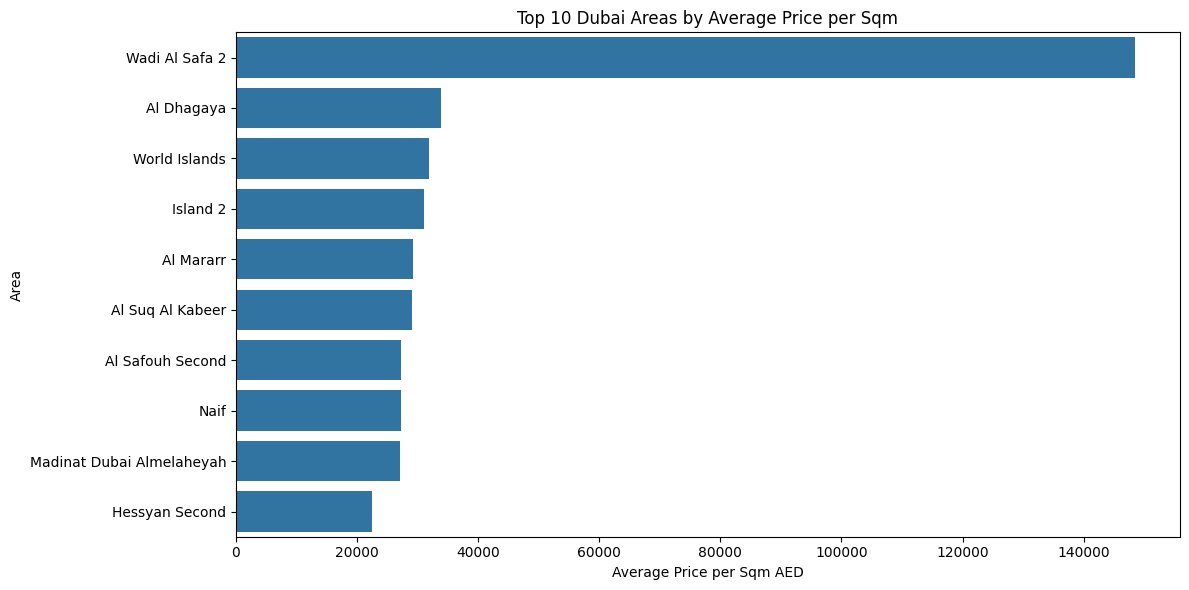

In [16]:
# Bar chart: Top 10 areas by average price per sqm

plt.figure(figsize=(12, 6))
sns.barplot(
    data=top_areas_price_per_sqm,
    x="average_price_per_sqm",
    y="area_name_en"
)

plt.title("Top 10 Dubai Areas by Average Price per Sqm")
plt.xlabel("Average Price per Sqm AED")
plt.ylabel("Area")
plt.tight_layout()

plt.savefig(FIGURES_DIR / "top_10_areas_by_price_per_sqm.png", dpi=300, bbox_inches="tight")
plt.show()

In [15]:
# Top 10 areas by average price per sqm
# Minimum 500 transactions required

top_areas_price_per_sqm = (
    area_price_summary[area_price_summary["total_transactions"] >= 500]
    .sort_values("average_price_per_sqm", ascending=False)
    .head(10)
)

top_areas_price_per_sqm

,area_name_en,total_transactions,average_price,median_price,average_price_per_sqm
235,Wadi Al Safa 2,10925,"1,285,515.71","667,648.00","148,478.12"
17,Al Dhagaya,576,"7,091,741.66","3,500,000.00","33,795.19"
243,World Islands,850,"4,903,024.87","1,427,500.00","31,809.78"
152,Island 2,728,"20,508,665.81","11,133,500.00","31,105.47"
52,Al Mararr,993,"8,709,611.77","5,300,000.00","29,292.25"
87,Al Suq Al Kabeer,854,"13,414,327.25","7,000,000.00","29,147.31"
85,Al Safouh Second,1510,"10,063,403.51","3,395,200.00","27,292.36"
195,Naif,1042,"11,146,328.39","5,633,346.00","27,270.34"
171,Madinat Dubai Almelaheyah,1488,"5,440,043.99","2,935,888.00","27,162.29"
149,Hessyan Second,1867,"3,328,208.43","2,852,540.00","22,521.46"


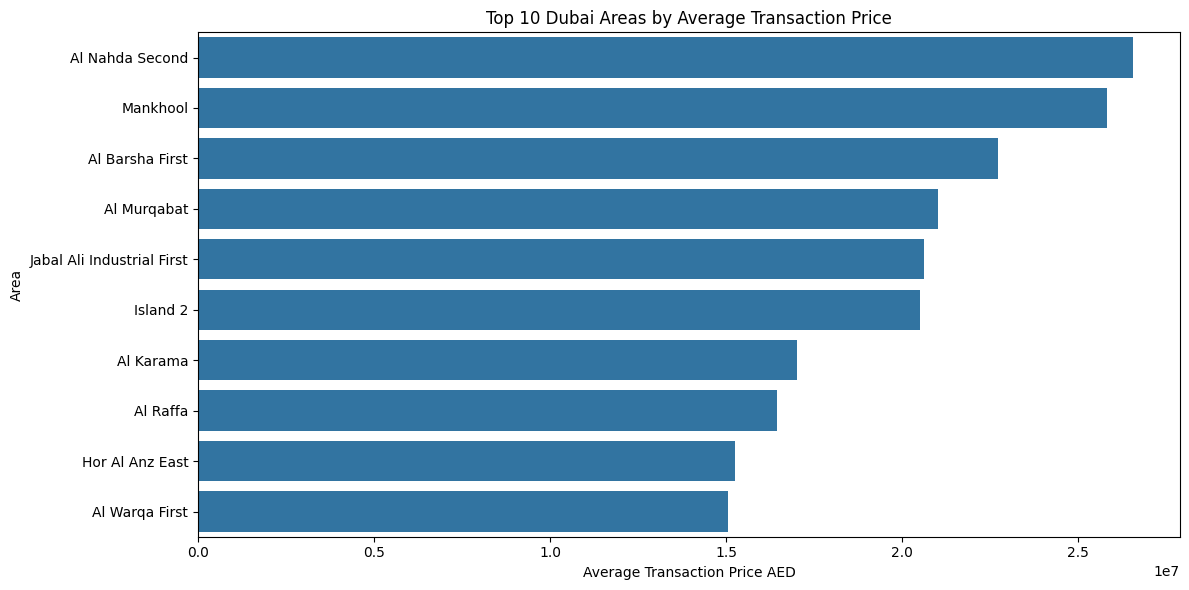

In [14]:
# Bar chart: Top 10 areas by average transaction price

plt.figure(figsize=(12, 6))
sns.barplot(
    data=top_areas_avg_price,
    x="average_price",
    y="area_name_en"
)

plt.title("Top 10 Dubai Areas by Average Transaction Price")
plt.xlabel("Average Transaction Price AED")
plt.ylabel("Area")
plt.tight_layout()

plt.savefig(FIGURES_DIR / "top_10_areas_by_average_price.png", dpi=300, bbox_inches="tight")
plt.show()

In [13]:
# Top 10 areas by average transaction price
# Minimum 500 transactions required to avoid misleading small-sample areas

area_price_summary = (
    df.groupby("area_name_en")
    .agg(
        total_transactions=("transaction_id", "count"),
        average_price=("actual_worth", "mean"),
        median_price=("actual_worth", "median"),
        average_price_per_sqm=("meter_sale_price", "mean")
    )
    .reset_index()
)

top_areas_avg_price = (
    area_price_summary[area_price_summary["total_transactions"] >= 500]
    .sort_values("average_price", ascending=False)
    .head(10)
)

top_areas_avg_price

,area_name_en,total_transactions,average_price,median_price,average_price_per_sqm
62,Al Nahda Second,959,"26,562,627.99","20,000,000.00","15,098.24"
172,Mankhool,874,"25,823,993.57","19,150,200.00","15,274.08"
8,Al Barsha First,1730,"22,710,414.22","14,000,000.00","15,074.32"
58,Al Murqabat,988,"21,012,288.63","12,000,000.00","19,242.28"
155,Jabal Ali Industrial First,1153,"20,617,595.48","19,938,000.00","9,634.53"
152,Island 2,728,"20,508,665.81","11,133,500.00","31,105.47"
39,Al Karama,929,"17,002,043.73","7,250,000.00","15,981.82"
73,Al Raffa,934,"16,455,148.61","7,505,780.00","14,805.15"
151,Hor Al Anz East,528,"15,247,371.17","4,425,000.00","6,726.15"
97,Al Warqa First,722,"15,063,628.20","10,363,807.50","9,302.82"


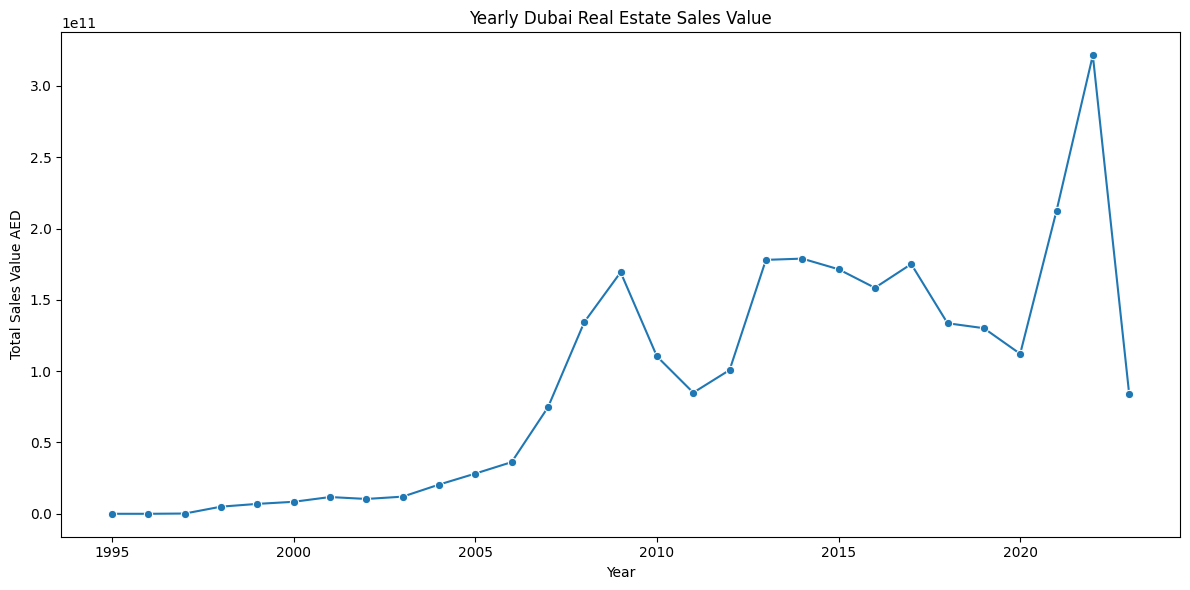

In [12]:
# Line chart: Yearly total sales value

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=yearly_summary,
    x="transaction_year",
    y="total_sales_value",
    marker="o"
)

plt.title("Yearly Dubai Real Estate Sales Value")
plt.xlabel("Year")
plt.ylabel("Total Sales Value AED")
plt.tight_layout()

plt.savefig(FIGURES_DIR / "yearly_sales_value_trend.png", dpi=300, bbox_inches="tight")
plt.show()

In [11]:
# Yearly market summary

yearly_summary = (
    df.groupby("transaction_year")
    .agg(
        total_transactions=("transaction_id", "count"),
        total_sales_value=("actual_worth", "sum"),
        average_price=("actual_worth", "mean"),
        median_price=("actual_worth", "median"),
        average_price_per_sqm=("meter_sale_price", "mean")
    )
    .reset_index()
)

yearly_summary

,transaction_year,total_transactions,total_sales_value,average_price,median_price,average_price_per_sqm
0,"1,995.00",3,"1,300,000.00","433,333.33","500,000.00",340.86
1,"1,996.00",2,"1,000,000.00","500,000.00","500,000.00",359.25
2,"1,997.00",57,"182,060,310.00","3,194,040.53","1,500,000.00","4,344.76"
3,"1,998.00",1442,"5,009,450,232.00","3,473,959.94","945,000.00","4,469.12"
4,"1,999.00",3134,"6,951,832,826.00","2,218,198.09","500,000.00","2,484.25"
5,"2,000.00",2764,"8,417,968,456.00","3,045,574.69","525,000.00","2,923.29"
6,"2,001.00",3435,"11,750,919,582.00","3,420,937.29","750,000.00","3,502.80"
7,"2,002.00",3704,"10,401,901,663.00","2,808,288.79","850,000.00","3,018.27"
8,"2,003.00",3644,"12,024,972,272.00","3,299,937.51","923,555.00","3,059.10"
9,"2,004.00",4622,"20,477,735,676.00","4,430,492.36","1,300,000.00","4,292.43"


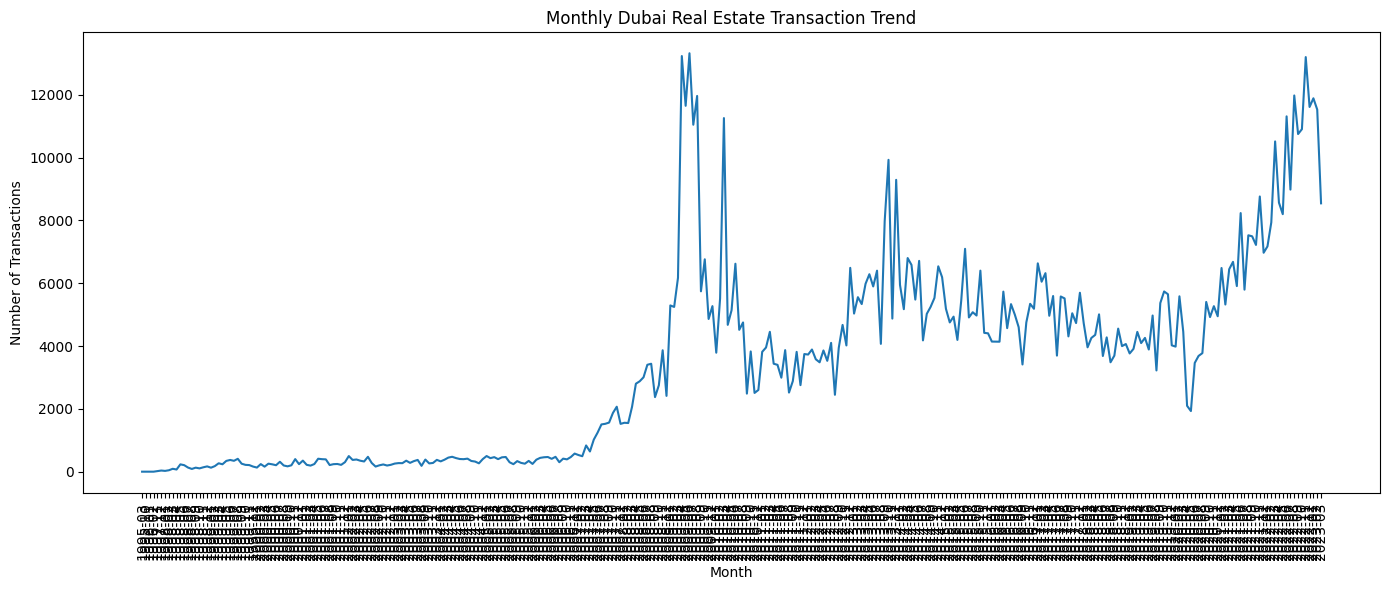

In [10]:
# Line chart: Monthly transaction count

plt.figure(figsize=(14, 6))
sns.lineplot(
    data=monthly_trend,
    x="transaction_year_month",
    y="total_transactions"
)

plt.title("Monthly Dubai Real Estate Transaction Trend")
plt.xlabel("Month")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=90)
plt.tight_layout()

plt.savefig(FIGURES_DIR / "monthly_transaction_trend.png", dpi=300, bbox_inches="tight")
plt.show()

In [9]:
# Monthly transaction trend

monthly_trend = (
    df.groupby("transaction_year_month")
    .agg(
        total_transactions=("transaction_id", "count"),
        total_sales_value=("actual_worth", "sum"),
        average_price=("actual_worth", "mean"),
        average_price_per_sqm=("meter_sale_price", "mean")
    )
    .reset_index()
)

monthly_trend.head()

,transaction_year_month,total_transactions,total_sales_value,average_price,average_price_per_sqm
0,1995-03,1,"300,000.00","300,000.00",215.28
1,1995-10,2,"1,000,000.00","500,000.00",403.65
2,1996-01,1,"500,000.00","500,000.00",359.71
3,1996-02,1,"500,000.00","500,000.00",358.80
4,1997-11,20,"43,541,480.00","2,177,074.00","5,907.96"


In [8]:
# Property type analysis

property_type_summary = (
    df.groupby("property_type_en")
    .agg(
        total_transactions=("transaction_id", "count"),
        total_sales_value=("actual_worth", "sum"),
        average_price=("actual_worth", "mean"),
        average_price_per_sqm=("meter_sale_price", "mean")
    )
    .sort_values("total_transactions", ascending=False)
    .reset_index()
)

property_type_summary

,property_type_en,total_transactions,total_sales_value,average_price,average_price_per_sqm
0,Unit,720974,"1,029,268,010,070.00","1,427,607.67","15,236.29"
1,Villa,214761,"644,208,625,305.00","2,999,653.69","6,422.07"
2,Land,78328,"515,384,002,287.00","6,579,818.23","8,363.74"
3,Building,30088,"481,492,339,886.00","16,002,803.11","13,509.11"


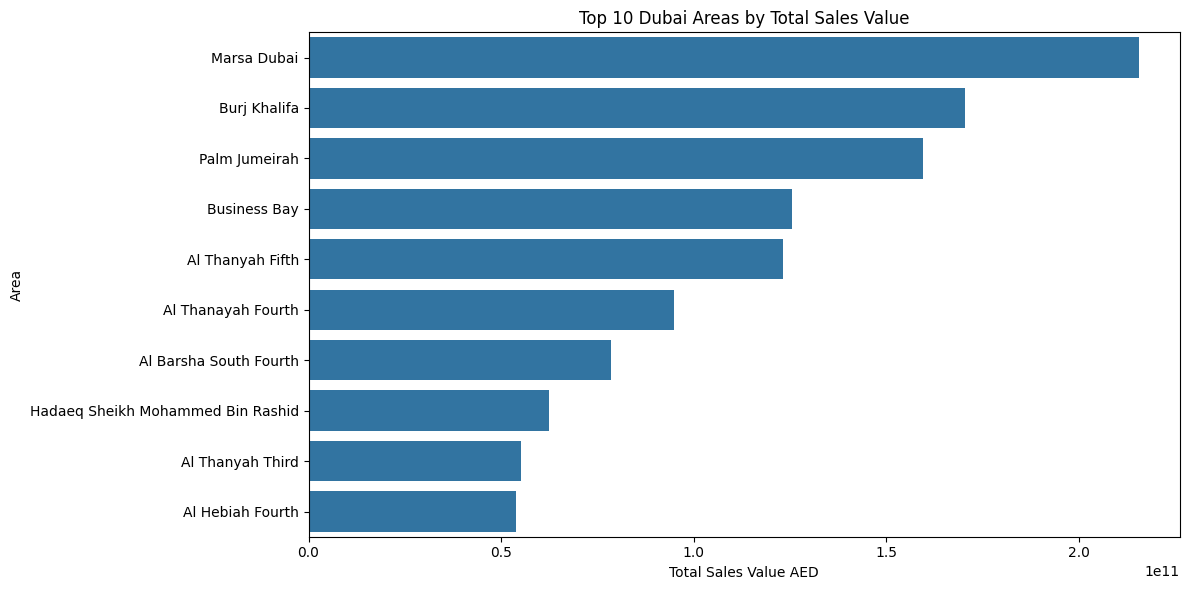

In [7]:
# Bar chart: Top 10 areas by total sales value

plt.figure(figsize=(12, 6))
sns.barplot(
    data=top_areas_sales,
    x="total_sales_value",
    y="area_name_en"
)

plt.title("Top 10 Dubai Areas by Total Sales Value")
plt.xlabel("Total Sales Value AED")
plt.ylabel("Area")
plt.tight_layout()

plt.savefig(FIGURES_DIR / "top_10_areas_by_sales_value.png", dpi=300, bbox_inches="tight")
plt.show()

In [6]:
# Top 10 areas by total sales value

top_areas_sales = (
    df.groupby("area_name_en")
    .agg(total_sales_value=("actual_worth", "sum"))
    .sort_values("total_sales_value", ascending=False)
    .head(10)
    .reset_index()
)

top_areas_sales

,area_name_en,total_sales_value
0,Marsa Dubai,"215,443,844,615.00"
1,Burj Khalifa,"170,479,258,019.00"
2,Palm Jumeirah,"159,438,221,733.00"
3,Business Bay,"125,562,514,033.00"
4,Al Thanyah Fifth,"123,062,412,774.00"
5,Al Thanayah Fourth,"94,991,754,822.00"
6,Al Barsha South Fourth,"78,589,642,014.00"
7,Hadaeq Sheikh Mohammed Bin Rashid,"62,507,432,315.00"
8,Al Thanyah Third,"55,028,485,941.00"
9,Al Hebiah Fourth,"53,775,764,463.00"


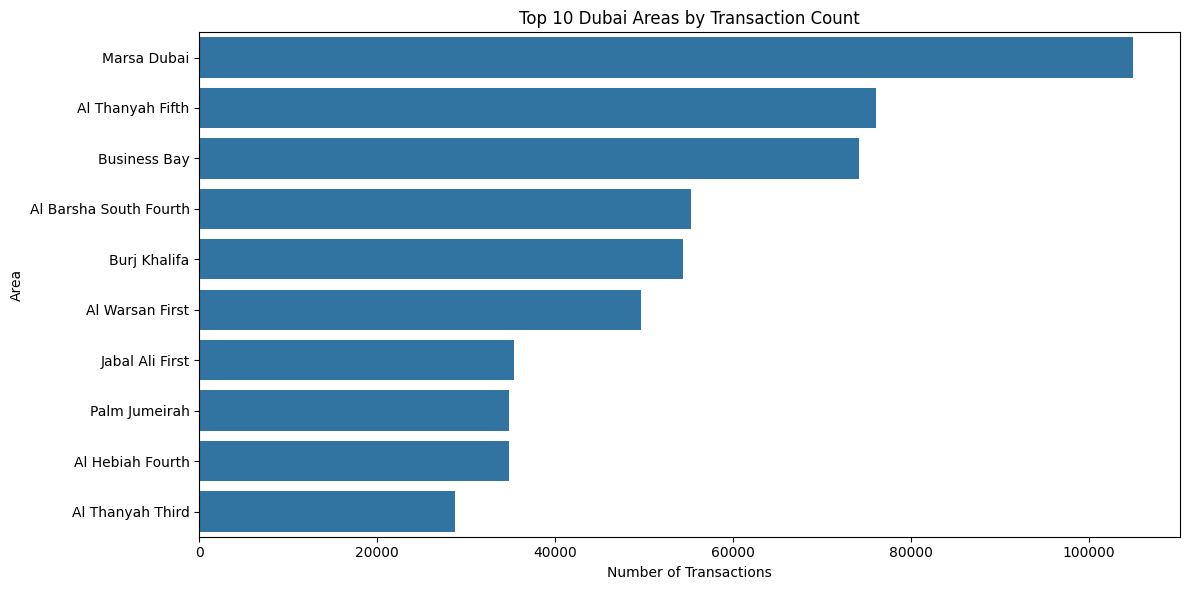

In [5]:
# Bar chart: Top 10 areas by transaction count

plt.figure(figsize=(12, 6))
sns.barplot(
    data=top_areas_transactions,
    x="total_transactions",
    y="area_name_en"
)

plt.title("Top 10 Dubai Areas by Transaction Count")
plt.xlabel("Number of Transactions")
plt.ylabel("Area")
plt.tight_layout()

plt.savefig(FIGURES_DIR / "top_10_areas_by_transactions.png", dpi=300, bbox_inches="tight")
plt.show()

In [4]:
# Top 10 areas by transaction count

top_areas_transactions = (
    df.groupby("area_name_en")
    .agg(total_transactions=("transaction_id", "count"))
    .sort_values("total_transactions", ascending=False)
    .head(10)
    .reset_index()
)

top_areas_transactions

,area_name_en,total_transactions
0,Marsa Dubai,105035
1,Al Thanyah Fifth,76155
2,Business Bay,74187
3,Al Barsha South Fourth,55265
4,Burj Khalifa,54356
5,Al Warsan First,49672
6,Jabal Ali First,35390
7,Palm Jumeirah,34861
8,Al Hebiah Fourth,34830
9,Al Thanyah Third,28781


In [3]:
# Dataset overview

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Date range:", df["instance_date"].min(), "to", df["instance_date"].max())
print("Total transactions:", df["transaction_id"].nunique())
print("Total sales value:", df["actual_worth"].sum())
print("Average transaction value:", df["actual_worth"].mean())
print("Median transaction value:", df["actual_worth"].median())
print("Average price per sqm:", df["meter_sale_price"].mean())

Rows: 1044151
Columns: 27
Date range: 1995-03-07 00:00:00 to 2023-03-17 00:00:00
Total transactions: 1044151
Total sales value: 2670352977548.0
Average transaction value: 2557439.467613401
Median transaction value: 1245500.0
Average price per sqm: 12858.06306821523


In [2]:
# Load cleaned dataset

file_path = PROCESSED_DATA_DIR / "dubai_real_estate_transactions_cleaned.csv"

df = pd.read_csv(file_path, low_memory=False)

df["instance_date"] = pd.to_datetime(df["instance_date"], errors="coerce")

print("Cleaned dataset loaded successfully.")
print("Shape:", df.shape)

df.head()

Cleaned dataset loaded successfully.
Shape: (1044151, 27)


,transaction_id,procedure_id,trans_group_en,procedure_name_en,instance_date,property_type_en,property_sub_type_en,property_usage_en,reg_type_en,area_id,area_name_en,building_name_en,project_name_en,master_project_en,nearest_metro_en,nearest_mall_en,nearest_landmark_en,rooms_en,has_parking,procedure_area,actual_worth,meter_sale_price,meter_rent_price,transaction_year,transaction_month,transaction_quarter,transaction_year_month
0,1-11-2001-165,11,Sales,Sell,2001-02-24,Land,Unknown,Commercial,Existing Properties,364,Al Wasl,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,0,"1,393.55","1,350,000.00",968.75,NaN,"2,001.00",2.00,1.00,2001-02
1,3-9-2004-223,9,Gifts,Grant,2004-12-13,Villa,Unknown,Commercial,Existing Properties,365,Al Hudaiba,Unknown,Unknown,Unknown,Al Jafiliya Metro Station,Dubai Mall,Burj Khalifa,Unknown,0,"1,728.00","2,790,000.00","1,614.58",NaN,"2,004.00",12.00,4.00,2004-12
2,2-13-1996-119,13,Mortgages,Mortgage Registration,2001-03-12,Land,Unknown,Commercial,Existing Properties,390,Burj Khalifa,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,0,929.03,"20,000,000.00","21,527.83",NaN,"2,001.00",3.00,1.00,2001-03
3,2-14-2005-222,14,Mortgages,Modify Mortgage,2005-09-20,Building,Unknown,Residential / Commercial,Existing Properties,388,Oud Metha,Unknown,Unknown,Unknown,Oud Metha Metro Station,Dubai Mall,Dubai International Airport,Unknown,0,"2,673.28","25,000,000.00","9,351.81",NaN,"2,005.00",9.00,3.00,2005-09
4,3-9-2012-874,9,Gifts,Grant,2012-10-11,Villa,Unknown,Residential,Existing Properties,276,Al Bada,Unknown,Unknown,Unknown,Trade Centre Metro Station,Dubai Mall,Burj Khalifa,Unknown,0,"1,541.17","9,000,000.00","5,839.72",NaN,"2,012.00",10.00,4.00,2012-10


In [1]:
# Dubai Real Estate Price Intelligence Dashboard
# Notebook 03: Exploratory Data Analysis

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:,.2f}".format)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"

print("Setup completed.")
print("Processed data folder:", PROCESSED_DATA_DIR)
print("Figures folder:", FIGURES_DIR)

Matplotlib is building the font cache; this may take a moment.


Setup completed.
Processed data folder: c:\Projects\dubai-real-estate-price-intelligence-dashboard\data\processed
Figures folder: c:\Projects\dubai-real-estate-price-intelligence-dashboard\reports\figures
